# TN-Initialized EM

**Problem recap:** the in-house FP KDE is truncated at ~0.5 because wrong candidates
only ever appear alongside easy confirmed spectra. The EM started from this biased
initialization and made it worse (FP tail shrank, LR at 1.0 rose from 23.6 → 44.1).

**Fix:** `hilic_tn.csv` contains 342 curator-confirmed wrong library matches scoring
0.59–1.0 (mean 0.836). These are the hard FPs that are completely absent from the
current FP distribution.

**Pipeline:**
1. Parse `msms` strings from hilic_tn → numpy peak arrays
2. Re-score each TN spectrum against its matched compound's NIST23 spectrum
   using the same `ms_entropy` + 0.05 Da tolerance as the main pipeline
3. Where NIST23 has no match for the compound: fall back to `library_search-identity_score`
4. Build FP KDE from re-scored TN values
5. Initialize EM with TN FP KDE + in-house TP KDE
6. Run EM loop and compare calibration to the naive EM

In [1]:
import pickle, warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm as sp_norm, gaussian_kde
from scipy.interpolate import interp1d
from scipy.special import kl_div
import ms_entropy as me

warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT     = '/Users/ellayoung/Desktop/metabolo_confi_score'
DATA_DIR = f'{ROOT}/data'
OUT_DIR  = f'{ROOT}/results/current'

SIGMA_BROAD    = 50.0
SIGMA_RT_BROAD = 300.0
P_MS1_NULL     = sp_norm.pdf(0.0, 0.0, SIGMA_BROAD)
P_RT_NULL      = sp_norm.pdf(0.0, 0.0, SIGMA_RT_BROAD)
NOTA_THRESH    = 0.6
sigma_M        = 4.21
sigma_RT_anno  = 14.1
sigma_RT_ref   = 19.1
p_novel_est    = 0.224
BW             = 0.05
MS2_TOL        = 0.05
sim_grid       = np.linspace(0.0, 1.0, 2000)

## Part 1 — Parse hilic_tn and Re-Score Against NIST23

For each TN spectrum:
- Parse the `msms` string → numpy peak array
- Look up `inchikey[:14]` in NIST23 → get all library spectra for the matched compound
- Compute entropy_similarity(tn_spectrum, each_library_spectrum) → take the max
- If no NIST23 match: use `library_search-identity_score` as fallback

In [2]:
def parse_msms_string(msms_str):
    """
    Parse 'mz:intensity mz:intensity ...' string into (N,2) float32 array.
    Returns None if string is empty or malformed.
    """
    if not isinstance(msms_str, str) or not msms_str.strip():
        return None
    peaks = []
    for token in msms_str.strip().split():
        try:
            mz, intensity = token.split(':')
            peaks.append([float(mz), float(intensity)])
        except ValueError:
            continue
    if len(peaks) == 0:
        return None
    return np.array(peaks, dtype=np.float32)


# Load TN data
tn_df = pd.read_csv(f'{DATA_DIR}/hilic_tn.csv')
print(f'TN spectra: {len(tn_df)}')
print(f'  Negative mode: {(tn_df["method"].str.contains("negative")).sum()}')
print(f'  Positive mode: {(tn_df["method"].str.contains("positive")).sum()}')
print(f'  Score range:   {tn_df["library_search-identity_score"].min():.3f} – '
      f'{tn_df["library_search-identity_score"].max():.3f}')

# Parse msms
tn_df['peaks_parsed'] = tn_df['msms'].map(parse_msms_string)
n_parsed = tn_df['peaks_parsed'].notna().sum()
print(f'\nSuccessfully parsed: {n_parsed}/{len(tn_df)} spectra')

TN spectra: 342
  Negative mode: 66
  Positive mode: 276
  Score range:   0.586 – 1.000

Successfully parsed: 342/342 spectra


In [3]:
# Build NIST23 InChIKey14 → peaks lookup
print('Building NIST23 InChIKey14 lookup...')
with open(f'{DATA_DIR}/NIST23_negative_entropy_selected_adducts.pkl', 'rb') as f:
    nist = pickle.load(f)

n_total = len(nist.precursor_mz_array)
nist_by_ik14 = defaultdict(list)
for i in range(n_total):
    s  = nist[i]
    ik = s.get('InChIKey', '') or ''
    if len(ik) < 14:
        continue
    peaks = s.get('peaks')
    if peaks is None or (hasattr(peaks, '__len__') and len(peaks) == 0):
        continue
    nist_by_ik14[ik[:14]].append(np.array(peaks, dtype=np.float32))

print(f'NIST23 unique InChIKey14s: {len(nist_by_ik14):,}')

# Check coverage of TN compounds in NIST23
tn_ik14s    = tn_df['inchikey'].str[:14]
n_in_nist   = tn_ik14s.isin(nist_by_ik14).sum()
print(f'TN compounds found in NIST23: {n_in_nist}/{len(tn_df)} ({n_in_nist/len(tn_df):.1%})')
print(f'Fallback to library_search-identity_score: {len(tn_df) - n_in_nist}')

Building NIST23 InChIKey14 lookup...


NIST23 unique InChIKey14s: 18,052
TN compounds found in NIST23: 96/342 (28.1%)
Fallback to library_search-identity_score: 246


In [4]:
# Re-score each TN spectrum
print('Re-scoring TN spectra...')
tn_entropy_sim = []
tn_source      = []   # 'nist23' or 'fallback'

for _, row in tn_df.iterrows():
    tn_peaks = row['peaks_parsed']
    ik14     = str(row['inchikey'])[:14]
    fallback = float(row['library_search-identity_score'])

    if tn_peaks is None:
        tn_entropy_sim.append(fallback)
        tn_source.append('fallback_no_peaks')
        continue

    lib_spectra = nist_by_ik14.get(ik14, [])
    if not lib_spectra:
        tn_entropy_sim.append(fallback)
        tn_source.append('fallback_not_in_nist')
        continue

    # Compute entropy similarity against all NIST23 spectra for this compound
    # Take the max (best library match — mimics MassWiki returning the top hit)
    best = 0.0
    for lib_peaks in lib_spectra:
        try:
            s = float(me.calculate_entropy_similarity(
                tn_peaks, lib_peaks, ms2_tolerance_in_da=MS2_TOL))
            if s > best:
                best = s
        except Exception:
            continue
    if best == 0.0:
        tn_entropy_sim.append(fallback)
        tn_source.append('fallback_sim_zero')
    else:
        tn_entropy_sim.append(best)
        tn_source.append('nist23')

tn_df['entropy_sim_rescored'] = tn_entropy_sim
tn_df['rescore_source']       = tn_source

print('\nRe-score source breakdown:')
print(pd.Series(tn_source).value_counts().to_string())
print()
print('Re-scored entropy similarity stats:')
print(tn_df['entropy_sim_rescored'].describe().round(3).to_string())

Re-scoring TN spectra...

Re-score source breakdown:
fallback_not_in_nist    246
nist23                   69
fallback_sim_zero        27

Re-scored entropy similarity stats:
count    342.000
mean       0.768
std        0.200
min        0.034
25%        0.743
50%        0.811
75%        0.885
max        1.000


## Part 2 — Visualise the TN FP Distribution

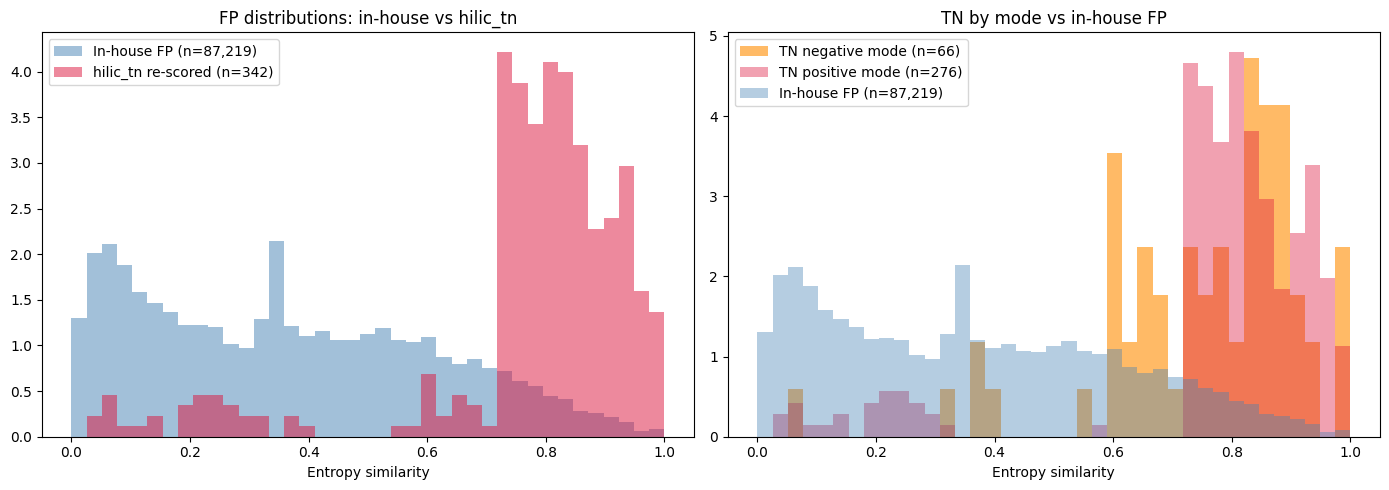

In-house FP above 0.5: 30.7%
TN scores  above 0.5: 90.9%
TN neg mode above 0.5: 92.4%


In [5]:
assertions  = pd.read_csv(f'{OUT_DIR}/assertions.csv')
fp_inhouse  = assertions[assertions['confirmed'] & ~assertions['correct']]['entropy_similarity'].dropna().values
tp_inhouse  = assertions[assertions['confirmed'] &  assertions['correct']]['entropy_similarity'].dropna().values
tn_scores   = tn_df['entropy_sim_rescored'].values

# Separate negative and positive mode TN scores
neg_mask     = tn_df['method'].str.contains('negative')
tn_neg       = tn_df.loc[neg_mask,  'entropy_sim_rescored'].values
tn_pos       = tn_df.loc[~neg_mask, 'entropy_sim_rescored'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = np.linspace(0, 1, 40)

ax = axes[0]
ax.hist(fp_inhouse, bins=bins, density=True, alpha=0.5,
        color='steelblue', label=f'In-house FP (n={len(fp_inhouse):,})')
ax.hist(tn_scores,  bins=bins, density=True, alpha=0.5,
        color='crimson',   label=f'hilic_tn re-scored (n={len(tn_scores)})')
ax.set_title('FP distributions: in-house vs hilic_tn')
ax.set_xlabel('Entropy similarity')
ax.legend()

ax = axes[1]
ax.hist(tn_neg, bins=bins, density=True, alpha=0.6,
        color='darkorange', label=f'TN negative mode (n={len(tn_neg)})')
ax.hist(tn_pos, bins=bins, density=True, alpha=0.4,
        color='crimson',    label=f'TN positive mode (n={len(tn_pos)})')
ax.hist(fp_inhouse, bins=bins, density=True, alpha=0.4,
        color='steelblue',  label=f'In-house FP (n={len(fp_inhouse):,})')
ax.set_title('TN by mode vs in-house FP')
ax.set_xlabel('Entropy similarity')
ax.legend()

plt.tight_layout()
plt.savefig(f'{ROOT}/viz/tn_fp_comparison.png', dpi=150)
plt.show()

print(f'In-house FP above 0.5: {(fp_inhouse > 0.5).mean():.1%}')
print(f'TN scores  above 0.5: {(tn_scores  > 0.5).mean():.1%}')
print(f'TN neg mode above 0.5: {(tn_neg > 0.5).mean():.1%}')

## Part 3 — Build TN-Augmented FP KDE

Two options:
- **TN only**: FP KDE entirely from hilic_tn re-scored values (n=342)
- **TN + in-house**: concatenate both, up-weight in-house to balance sample sizes

We try both as EM initializations.

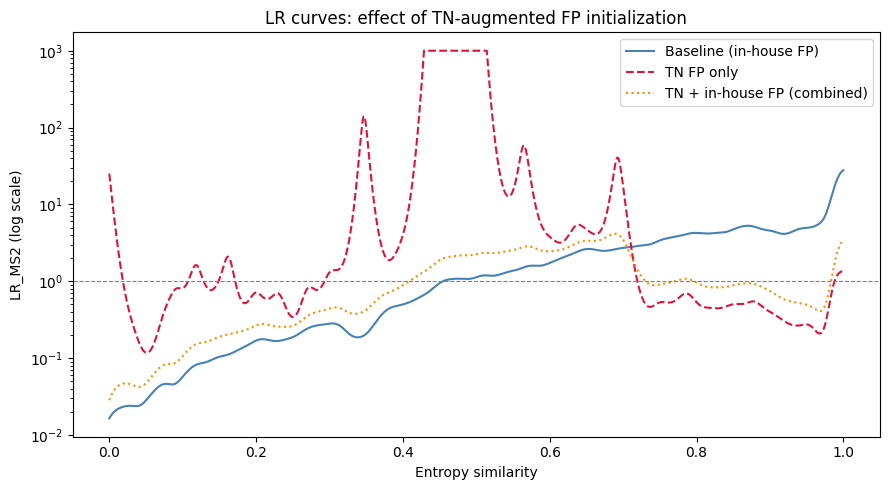

LR at sim=1.0 (Baseline): 27.9
LR at sim=1.0 (TN only): 1.4
LR at sim=1.0 (Combined): 3.4


In [6]:
def make_lr_grid(tp_grid, fp_grid):
    return np.clip(tp_grid / (fp_grid + 1e-10), 0.0, 1000.0)


def null_adj_lr_fn(lr_grid_):
    def fn(sims, H, alpha_=10.0):
        lam    = 1.0 - np.exp(-alpha_ * H)
        abs_lr = np.interp(sims, sim_grid, lr_grid_)
        return lam * abs_lr + (1.0 - lam)
    return fn


def grid_kde(scores, bw=BW):
    """Fit KDE and evaluate on sim_grid."""
    k = gaussian_kde(scores, bw_method=bw)
    return np.clip(k(sim_grid), 1e-10, None)


def interp_kde(grid):
    """Wrap a pre-evaluated grid as a callable."""
    return interp1d(sim_grid, grid, bounds_error=False, fill_value='extrapolate')


# ── baseline (in-house only) ───────────────────────────────────────────────
tp_grid_base = grid_kde(tp_inhouse)
fp_grid_base = grid_kde(fp_inhouse)
lr_grid_base = make_lr_grid(tp_grid_base, fp_grid_base)

# ── TN-only FP ───────────────────────────────────────────────────────────
fp_grid_tn   = grid_kde(tn_scores)
lr_grid_tn   = make_lr_grid(tp_grid_base, fp_grid_tn)

# ── TN + in-house FP (concatenated, in-house up-weighted to same n) ───────
n_tn     = len(tn_scores)
n_fp_inh = len(fp_inhouse)
fp_combined_scores  = np.concatenate([tn_scores, fp_inhouse])
fp_combined_weights = np.concatenate([
    np.ones(n_tn) / n_tn,
    np.ones(n_fp_inh) / n_fp_inh
])
fp_combined_weights /= fp_combined_weights.sum()
kde_fp_combined     = gaussian_kde(fp_combined_scores, bw_method=BW,
                                    weights=fp_combined_weights)
fp_grid_combined    = np.clip(kde_fp_combined(sim_grid), 1e-10, None)
lr_grid_combined    = make_lr_grid(tp_grid_base, fp_grid_combined)

# ── compare LR curves ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sim_grid, lr_grid_base,     label='Baseline (in-house FP)',      color='steelblue')
ax.plot(sim_grid, lr_grid_tn,       label='TN FP only',                  color='crimson',    linestyle='--')
ax.plot(sim_grid, lr_grid_combined, label='TN + in-house FP (combined)', color='darkorange', linestyle=':')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax.set_yscale('log')
ax.set_xlabel('Entropy similarity')
ax.set_ylabel('LR_MS2 (log scale)')
ax.set_title('LR curves: effect of TN-augmented FP initialization')
ax.legend()
plt.tight_layout()
plt.savefig(f'{ROOT}/viz/tn_lr_curves.png', dpi=150)
plt.show()

for name, lr_g in [('Baseline', lr_grid_base),
                    ('TN only',  lr_grid_tn),
                    ('Combined', lr_grid_combined)]:
    print(f'LR at sim=1.0 ({name}): {np.interp(1.0, sim_grid, lr_g):.1f}')

## Part 4 — EM Loop with TN Initialization

Same EM as `em_soft_label.ipynb` but starting from the TN-augmented FP KDE.
The better initialization means the E-step will assign real FP weight to
high-similarity hits, which the M-step can then maintain.

In [7]:
# ── load joint data ────────────────────────────────────────────────────────
print('Loading joint hit data...')
spectra_raw = pd.read_csv(f'{DATA_DIR}/ttof+neg+hilic.csv')
hits_a      = pd.read_csv(f'{DATA_DIR}/hilic_ttof_neg_masswiki_hits_new.csv')
hits_u      = pd.read_csv(f'{DATA_DIR}/hilic_ttof_neg_masswiki_hits_unconfirmed.csv')
hits_raw    = pd.concat([hits_a, hits_u], ignore_index=True)

specs = spectra_raw[['wiki_id','rt','precursor_mz','entropy','is_manual_annotated']].copy()
specs['wiki_id']   = specs['wiki_id'].astype(str)
specs['confirmed'] = specs['is_manual_annotated'].fillna(False).astype(bool)
hits_raw['wiki_id'] = hits_raw['wiki_id'].astype(str)

joint = hits_raw.merge(
    specs[['wiki_id','rt','precursor_mz','entropy','confirmed']],
    on='wiki_id', how='inner'
)
joint['delta_ppm'] = ((joint['precursor_mz'] - joint['lib_precursor_mz'])
                       / joint['lib_precursor_mz'] * 1e6)
joint['delta_rt']  = joint.apply(
    lambda r: r['anno_delta_rt']
              if r['hit_source'] == 'annotation' and pd.notna(r.get('anno_delta_rt'))
              else (r['rt'] - r['predicted_rt_hilic']
                    if r['hit_source'] == 'reference' and pd.notna(r.get('predicted_rt_hilic'))
                    else np.nan),
    axis=1
)
correct_map = assertions.groupby(['wiki_id','lib_name'])['correct'].first().to_dict()
joint['correct'] = joint.apply(
    lambda r: correct_map.get((str(r['wiki_id']), r['lib_name']), False), axis=1
)
anno_wids   = set(specs[specs['confirmed']]['wiki_id'])
anno_joint  = joint[joint['wiki_id'].isin(anno_wids)].copy()
unno_joint  = joint[~joint['wiki_id'].isin(anno_wids)].reset_index(drop=True)
print(f'Annotated: {len(anno_joint):,}  Unannotated: {len(unno_joint):,}')

Loading joint hit data...


Annotated: 137,490  Unannotated: 150,415


In [8]:
# ── EM helpers ─────────────────────────────────────────────────────────────
def e_step(df, lr_fn):
    post_vals = np.zeros(len(df))
    for wid, g in df.groupby('wiki_id'):
        H      = float(g['entropy'].iloc[0])
        N      = len(g)
        LR_ms2 = lr_fn(g['entropy_similarity'].fillna(0).values, H)
        p_ms1  = sp_norm.pdf(g['delta_ppm'].values, 0.0, sigma_M)
        LR_ms1 = p_ms1 / P_MS1_NULL
        LR_rt  = np.ones(N)
        has_rt = g['delta_rt'].notna().values
        dr     = g['delta_rt'].fillna(0.0).values
        m_a = (g['hit_source'] == 'annotation').values & has_rt
        m_r = (g['hit_source'] == 'reference').values  & has_rt
        if m_a.any(): LR_rt[m_a] = sp_norm.pdf(dr[m_a], 0.0, sigma_RT_anno) / P_RT_NULL
        if m_r.any(): LR_rt[m_r] = sp_norm.pdf(dr[m_r], 0.0, sigma_RT_ref)  / P_RT_NULL
        priors = np.full(N, (1.0 - p_novel_est) / N)
        unnorm = priors * LR_ms2 * LR_ms1 * LR_rt
        total  = unnorm.sum() + p_novel_est
        post   = unnorm / total if total > 1e-300 else np.full(N, 1.0/N)
        post_vals[g.index - df.index[0]] = post
    return pd.Series(post_vals, index=df.index)


def m_step(anno_df, unno_df, unno_post, tp_grid_prev, fp_grid_prev,
           mix_alpha=0.3):
    anno_sim  = anno_df['entropy_similarity'].fillna(0).values
    anno_w_tp = anno_df['correct'].astype(float).values
    anno_w_fp = 1.0 - anno_w_tp
    unno_sim  = unno_df['entropy_similarity'].fillna(0).values
    unno_w_tp = unno_post.values
    unno_w_fp = 1.0 - unno_w_tp
    scale     = len(anno_df) / len(unno_df)
    all_sim   = np.concatenate([anno_sim,  unno_sim])
    all_w_tp  = np.clip(np.concatenate([anno_w_tp, unno_w_tp * scale]), 1e-6, None)
    all_w_fp  = np.clip(np.concatenate([anno_w_fp, unno_w_fp * scale]), 1e-6, None)
    kde_tp_em = gaussian_kde(all_sim, bw_method=BW, weights=all_w_tp / all_w_tp.sum())
    kde_fp_em = gaussian_kde(all_sim, bw_method=BW, weights=all_w_fp / all_w_fp.sum())
    tp_em = np.clip(kde_tp_em(sim_grid), 1e-10, None)
    fp_em = np.clip(kde_fp_em(sim_grid), 1e-10, None)
    tp_new = mix_alpha * tp_em + (1 - mix_alpha) * tp_grid_prev
    fp_new = mix_alpha * fp_em + (1 - mix_alpha) * fp_grid_prev
    return (np.clip(tp_new, 1e-10, None),
            np.clip(fp_new, 1e-10, None))


def calibration_table(df, lr_fn):
    BIN_EDGES = [(0.90,1.01,'>0.90'),(0.70,0.90,'0.70-0.90'),
                 (0.50,0.70,'0.50-0.70'),(0.30,0.50,'0.30-0.50'),(0.0,0.30,'<0.30')]
    top_rows = []
    for wid, g in df.groupby('wiki_id'):
        H      = float(g['entropy'].iloc[0])
        N      = len(g)
        LR_ms2 = lr_fn(g['entropy_similarity'].fillna(0).values, H)
        p_ms1  = sp_norm.pdf(g['delta_ppm'].values, 0.0, sigma_M)
        LR_ms1 = p_ms1 / P_MS1_NULL
        LR_rt  = np.ones(N)
        has_rt = g['delta_rt'].notna().values
        dr     = g['delta_rt'].fillna(0.0).values
        m_a = (g['hit_source'] == 'annotation').values & has_rt
        m_r = (g['hit_source'] == 'reference').values  & has_rt
        if m_a.any(): LR_rt[m_a] = sp_norm.pdf(dr[m_a], 0.0, sigma_RT_anno) / P_RT_NULL
        if m_r.any(): LR_rt[m_r] = sp_norm.pdf(dr[m_r], 0.0, sigma_RT_ref)  / P_RT_NULL
        priors = np.full(N, (1.0 - p_novel_est) / N)
        unnorm = priors * LR_ms2 * LR_ms1 * LR_rt
        total  = unnorm.sum() + p_novel_est
        post   = unnorm / total if total > 1e-300 else np.full(N, 1.0/N)
        p_nov  = float(p_novel_est / total) if total > 1e-300 else p_novel_est
        best   = post.argmax()
        top_rows.append({'post_top': float(post[best]),
                         'correct' : bool(g['correct'].iloc[best]),
                         'P_novel' : p_nov})
    df_t   = pd.DataFrame(top_rows)
    called = df_t[df_t['P_novel'] < NOTA_THRESH]
    out = []
    for lo, hi, lbl in BIN_EDGES:
        sub = called[(called['post_top'] >= lo) & (called['post_top'] < hi)]
        out.append({'bin': lbl, 'n': len(sub),
                    'acc': round(sub['correct'].mean(), 4) if len(sub) > 0 else np.nan})
    return pd.DataFrame(out)


print('Helpers defined.')

Helpers defined.


In [9]:
N_ITER    = 6
MIX_ALPHA = 0.3

def run_em(tp_grid_init, fp_grid_init, label):
    """Run EM from a given initialization. Returns history dict."""
    hist = {'iter':[], 'tp_grid':[], 'fp_grid':[], 'lr_grid':[], 'calibration':[]}

    tp_cur = tp_grid_init.copy()
    fp_cur = fp_grid_init.copy()
    lr_cur = make_lr_grid(tp_cur, fp_cur)

    cal_0 = calibration_table(anno_joint, null_adj_lr_fn(lr_cur))
    hist['iter'].append(0);  hist['tp_grid'].append(tp_cur.copy())
    hist['fp_grid'].append(fp_cur.copy()); hist['lr_grid'].append(lr_cur.copy())
    hist['calibration'].append(cal_0)

    print(f'\n{label}')
    print(f'{"Iter":>5} {"FP>0.5":>8} {"LR@1.0":>8} {"acc>0.90":>10} {"acc 0.7-0.9":>12}')
    print('-' * 52)

    def _log(it, fp_g, lr_g, cal):
        fp_tail = fp_g[sim_grid > 0.5].sum() / fp_g.sum()
        lr1     = np.interp(1.0, sim_grid, lr_g)
        a90  = cal[cal['bin']=='>0.90']['acc'].values
        a70  = cal[cal['bin']=='0.70-0.90']['acc'].values
        print(f'{it:>5} {fp_tail:>8.3f} {lr1:>8.1f}'
              f' {float(a90[0]) if len(a90) else np.nan:>10.4f}'
              f' {float(a70[0]) if len(a70) else np.nan:>12.4f}')

    _log(0, fp_cur, lr_cur, cal_0)

    for it in range(1, N_ITER + 1):
        lr_fn_cur = null_adj_lr_fn(lr_cur)
        unno_post = e_step(unno_joint, lr_fn_cur)
        tp_cur, fp_cur = m_step(anno_joint, unno_joint, unno_post,
                                  tp_cur, fp_cur, mix_alpha=MIX_ALPHA)
        lr_cur = make_lr_grid(tp_cur, fp_cur)
        cal_it = calibration_table(anno_joint, null_adj_lr_fn(lr_cur))
        hist['iter'].append(it);  hist['tp_grid'].append(tp_cur.copy())
        hist['fp_grid'].append(fp_cur.copy()); hist['lr_grid'].append(lr_cur.copy())
        hist['calibration'].append(cal_it)
        _log(it, fp_cur, lr_cur, cal_it)

    return hist


# Run both initializations
hist_naive = run_em(tp_grid_base, fp_grid_base,
                    'Naive EM (in-house FP initialization)')
hist_tn    = run_em(tp_grid_base, fp_grid_combined,
                    'TN-initialized EM (TN + in-house FP initialization)')


Naive EM (in-house FP initialization)
 Iter   FP>0.5   LR@1.0   acc>0.90  acc 0.7-0.9
----------------------------------------------------
    0    0.308     27.9     1.0000       0.9955


    1    0.264     31.8     1.0000       0.9954


    2    0.233     35.4     1.0000       0.9952


    3    0.211     38.7     1.0000       0.9951


    4    0.195     41.6     1.0000       0.9950


...

    2    0.379      6.0     1.0000       1.0000


    3    0.313      8.1     1.0000       1.0000


    4    0.267     10.7     1.0000       1.0000


    5    0.235     13.8     1.0000       1.0000


    6    0.212     17.6     1.0000       1.0000


## Part 5 — Compare FP Evolution

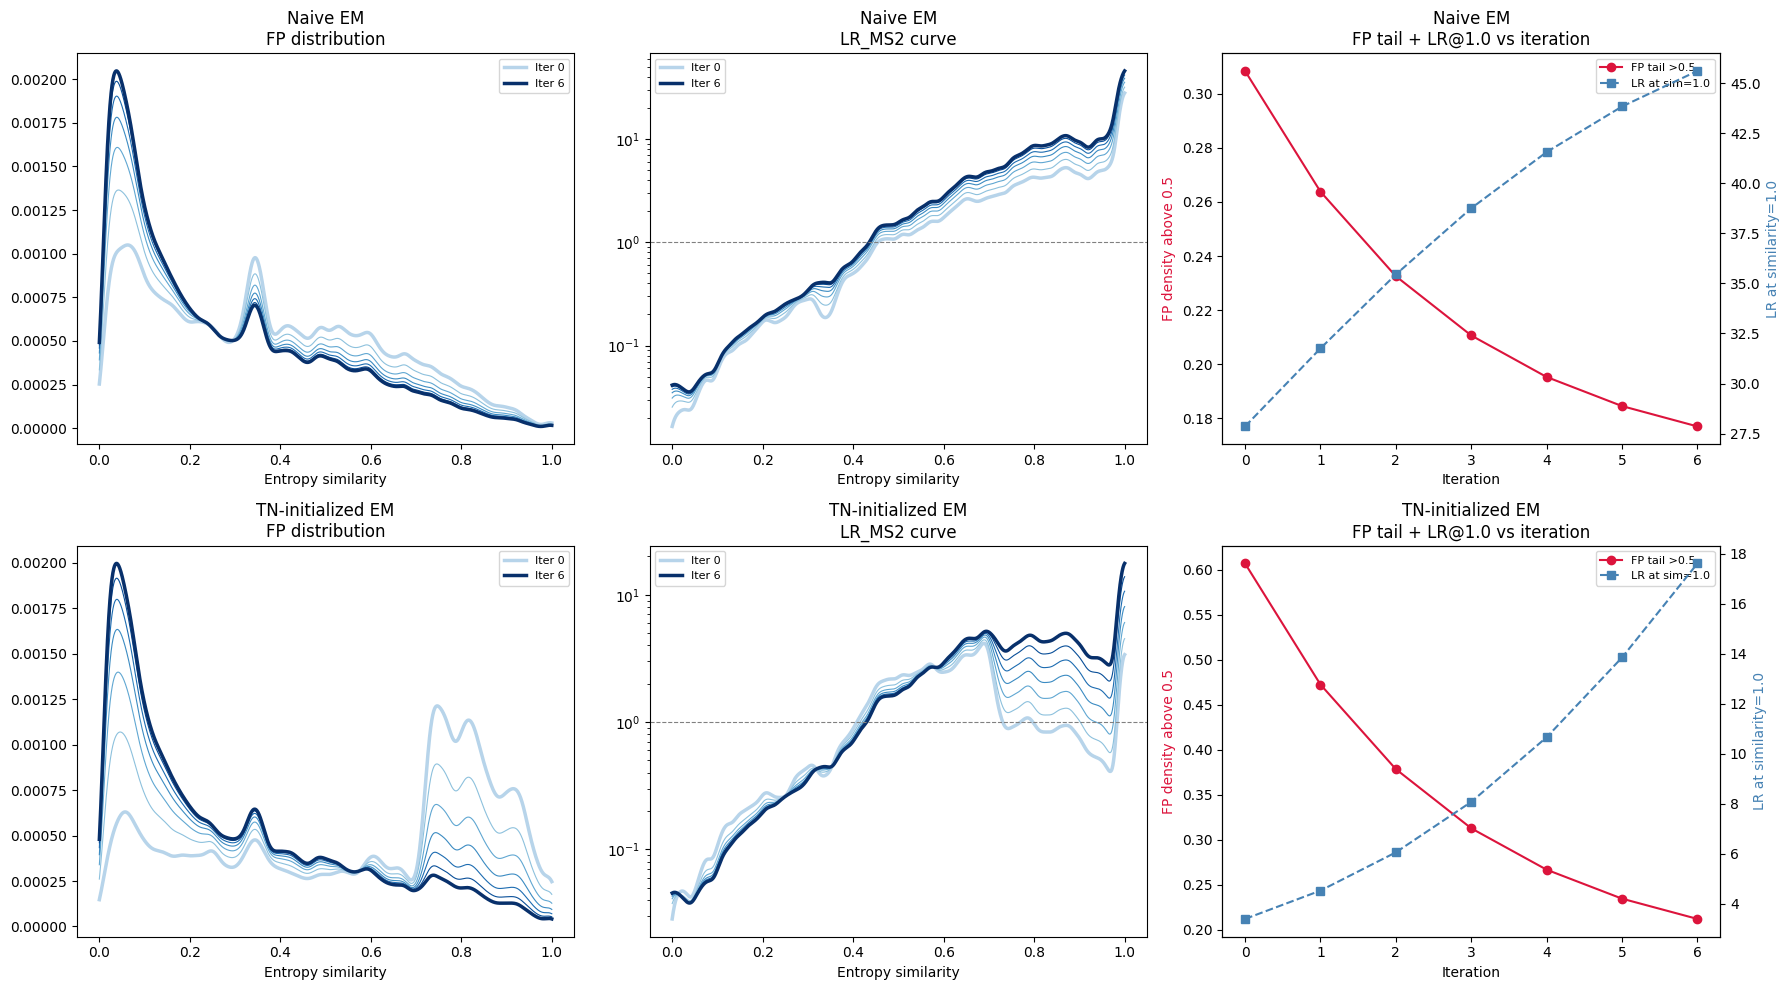

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cmap = plt.cm.Blues

for row_idx, (hist, title) in enumerate([
    (hist_naive, 'Naive EM'),
    (hist_tn,    'TN-initialized EM')
]):
    iters  = hist['iter']
    colors = [cmap(0.3 + 0.7 * i / max(len(iters)-1, 1)) for i in range(len(iters))]

    # FP evolution
    ax = axes[row_idx][0]
    for i, (it, fp_g) in enumerate(zip(iters, hist['fp_grid'])):
        lw    = 2.5 if it in (0, iters[-1]) else 0.8
        label = f'Iter {it}' if it in (0, iters[-1]) else None
        ax.plot(sim_grid, fp_g / fp_g.sum(), color=colors[i], lw=lw, label=label)
    ax.set_title(f'{title}\nFP distribution')
    ax.set_xlabel('Entropy similarity')
    ax.legend(fontsize=8)

    # LR evolution
    ax = axes[row_idx][1]
    for i, (it, lr_g) in enumerate(zip(iters, hist['lr_grid'])):
        lw    = 2.5 if it in (0, iters[-1]) else 0.8
        label = f'Iter {it}' if it in (0, iters[-1]) else None
        ax.plot(sim_grid, lr_g, color=colors[i], lw=lw, label=label)
    ax.axhline(1.0, color='gray', linestyle='--', lw=0.8)
    ax.set_yscale('log')
    ax.set_title(f'{title}\nLR_MS2 curve')
    ax.set_xlabel('Entropy similarity')
    ax.legend(fontsize=8)

    # FP tail across iterations
    ax = axes[row_idx][2]
    fp_tails = [fp_g[sim_grid > 0.5].sum() / fp_g.sum() for fp_g in hist['fp_grid']]
    lr_at_1  = [np.interp(1.0, sim_grid, lr_g) for lr_g in hist['lr_grid']]
    ax2 = ax.twinx()
    ax.plot(iters, fp_tails, marker='o', color='crimson',   label='FP tail >0.5')
    ax2.plot(iters, lr_at_1, marker='s', color='steelblue', linestyle='--', label='LR at sim=1.0')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('FP density above 0.5', color='crimson')
    ax2.set_ylabel('LR at similarity=1.0', color='steelblue')
    ax.set_title(f'{title}\nFP tail + LR@1.0 vs iteration')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.savefig(f'{ROOT}/viz/tn_em_comparison.png', dpi=150)
plt.show()

## Part 6 — Final Calibration: Three-Way Comparison

In [11]:
cal_naive_final = hist_naive['calibration'][-1].copy()
cal_tn_final    = hist_tn['calibration'][-1].copy()
cal_baseline    = hist_naive['calibration'][0].copy()

cal_baseline['model']    = 'Baseline'
cal_naive_final['model'] = f'Naive EM ({N_ITER} iter)'
cal_tn_final['model']    = f'TN-init EM ({N_ITER} iter)'

comp = pd.concat([cal_baseline, cal_naive_final, cal_tn_final])
print('Calibration comparison (accuracy):')
print(comp.pivot(index='bin', columns='model', values='acc').round(4).to_string())
print()
print('N called per bin:')
print(comp.pivot(index='bin', columns='model', values='n').to_string())

print('\nFP tail summary:')
for label, hist in [('Naive EM init',   hist_naive),
                     ('TN-init EM init', hist_tn)]:
    fp0 = hist['fp_grid'][0]
    fpN = hist['fp_grid'][-1]
    lr0 = np.interp(1.0, sim_grid, hist['lr_grid'][0])
    lrN = np.interp(1.0, sim_grid, hist['lr_grid'][-1])
    print(f'  {label}:')
    print(f'    FP tail >0.5:  {fp0[sim_grid>0.5].sum()/fp0.sum():.3f} → {fpN[sim_grid>0.5].sum()/fpN.sum():.3f}')
    print(f'    LR at sim=1.0: {lr0:.1f} → {lrN:.1f}')

Calibration comparison (accuracy):
model      Baseline  Naive EM (6 iter)  TN-init EM (6 iter)
bin                                                        
0.30-0.50    0.9826             0.9796               0.9696
0.50-0.70    0.9883             0.9909               0.9893
0.70-0.90    0.9955             0.9950               1.0000
<0.30        0.8872             0.8965               0.9027
>0.90        1.0000             1.0000               1.0000

N called per bin:
model      Baseline  Naive EM (6 iter)  TN-init EM (6 iter)
bin                                                        
0.30-0.50       459                491                  395
0.50-0.70       343                329                  187
0.70-0.90       222                200                   92
<0.30           745                744                 1120
>0.90            89                 96                   66

FP tail summary:
  Naive EM init:
    FP tail >0.5:  0.308 → 0.177
    LR at sim=1.0: 27.9 → 45.6
  TN-in